In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, GlobalAveragePooling1D, Input, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

In [71]:
btc_5years = pd.read_csv('BTC_USDT_5_years.csv')
btc_5years.set_index('date', inplace = True)

eth_5years = pd.read_csv('ETH_USDT_5_years.csv')
eth_5years.set_index('date', inplace = True)

ltc_5years = pd.read_csv('LTC_USDT_5_years.csv')
ltc_5years.set_index('date', inplace = True)

xrp_5years = pd.read_csv('XRP_USDT_5_years.csv')
xrp_5years.set_index('date', inplace = True)

In [ ]:
def hybrid_forecast(data, forecast_days=30, lags=20, lookback=20):
    
    # Признаки (все, кроме цены)
    feature_cols = [col for col in data.columns if col != 'close']
    price = data['close'].values
    
    # Создаём X с лагами ВСЕХ признаков
    X = []
    for i in range(lags, len(price)):
        row = []
        # Лаги цены (участвуют!)
        row.extend(price[i-lags:i])
        # Лаги остальных признаков
        for col in feature_cols:
            row.extend(data[col].values[i-lags:i])
        X.append(row)
    
    X = np.array(X)
    y = price[lags:]
    
    print(f"   Shape X: {X.shape} (={lags} ценовых лагов + {lags * len(feature_cols)} др. лагов)")
    
    # Train/test split
    split = len(X) - forecast_days
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    # XGBoost
    print("\nTraining XGBoost...")
    xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
    xgb.fit(X_train, y_train)
    xgb_train_pred = xgb.predict(X_train)
    xgb_test_pred = xgb.predict(X_test)
    
    # LSTM на остатках
    print("Training LSTM on residuals...")
    residuals = y_train - xgb_train_pred
    scaler = MinMaxScaler()
    res_scaled = scaler.fit_transform(residuals.reshape(-1, 1))
    
    X_lstm, y_lstm = [], []
    for i in range(lookback, len(res_scaled)):
        X_lstm.append(res_scaled[i-lookback:i])
        y_lstm.append(res_scaled[i])
    X_lstm = np.array(X_lstm)
    y_lstm = np.array(y_lstm)
    
    lstm = Sequential([
        LSTM(64, return_sequences=True, input_shape=(lookback, 1)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    lstm.compile(optimizer='adam', loss='mse')
    lstm.fit(X_lstm, y_lstm, epochs=50, batch_size=32, validation_split=0.2, 
             callbacks=[EarlyStopping(patience=5, restore_best_weights=True)], shuffle= False, verbose=0)
    
    # Прогноз остатков на тесте
    last_seq = scaler.transform(residuals[-lookback:].reshape(-1, 1)).flatten()
    residual_preds = []
    for _ in range(len(X_test)):
        pred = lstm.predict(last_seq.reshape(1, lookback, 1), verbose=0)[0, 0]
        residual_preds.append(pred)
        last_seq = np.append(last_seq[1:], pred)
    residual_preds = scaler.inverse_transform(np.array(residual_preds).reshape(-1, 1)).flatten()
    
    # Гибридный прогноз
    hybrid_pred = xgb_test_pred + residual_preds
    
    # Метрики
    mae = mean_absolute_error(y_test, hybrid_pred)
    mape = mean_absolute_percentage_error(y_test, hybrid_pred) * 100
    xgb_mape = mean_absolute_percentage_error(y_test, xgb_test_pred) * 100
    
    print(f"\n📊 РЕЗУЛЬТАТЫ:")
    print(f"   XGBoost MAPE: {xgb_mape:.2f}%")
    print(f"   Hybrid MAPE:  {mape:.2f}%")
    print(f"   Улучшение:    {xgb_mape - mape:.2f}%")
    print(f"   MAE:          ${mae:,.2f}")
    
    plt.figure(figsize=(14, 6))
    plt.plot(y_test, label='Actual Price', linewidth=2, color='blue')
    plt.plot(hybrid_pred, label='Hybrid Forecast (XGB+LSTM)', linewidth=2, color='red', linestyle='--')
    plt.plot(xgb_test_pred, label='XGBoost Forecast', linewidth=1.5, color='orange', alpha=0.7)
    plt.title(f'Hybrid Model: XGBoost + LSTM\nForecast: {forecast_days} days | MAPE: {mape:.2f}% | MAE: ${mae:,.2f}')
    plt.xlabel('Days')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    
    return {
        'predictions': hybrid_pred,
        'actual': y_test,
        'mae': mae,
        'mape': mape,
        'models': {'xgb': xgb, 'lstm': lstm, 'scaler': scaler}
    }

## XGBOOST + LSTM FORECASTS

   Shape X: (1814, 40) (=10 ценовых лагов + 30 др. лагов)

Training XGBoost...
Training LSTM on residuals...


d:\forecast_service\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



📊 РЕЗУЛЬТАТЫ:
   XGBoost MAPE: 2.51%
   Hybrid MAPE:  2.51%
   Улучшение:    0.00%
   MAE:          $1,952.53


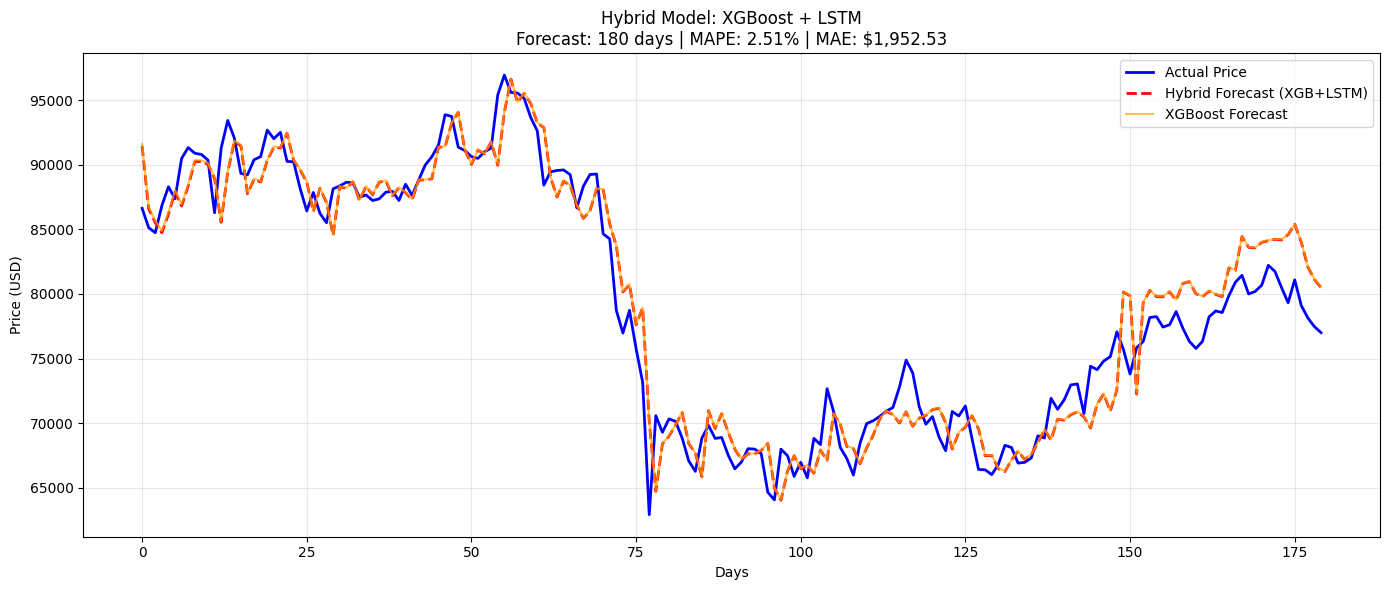

In [33]:
#BTC
btc_xgb_lstm = hybrid_forecast(btc_5years, forecast_days = 180, lags = 10, lookback = 50) 

   Shape X: (1804, 80) (=20 ценовых лагов + 60 др. лагов)

Training XGBoost...
Training LSTM on residuals...


d:\forecast_service\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



📊 РЕЗУЛЬТАТЫ:
   XGBoost MAPE: 3.44%
   Hybrid MAPE:  3.35%
   Улучшение:    0.10%
   MAE:          $81.13


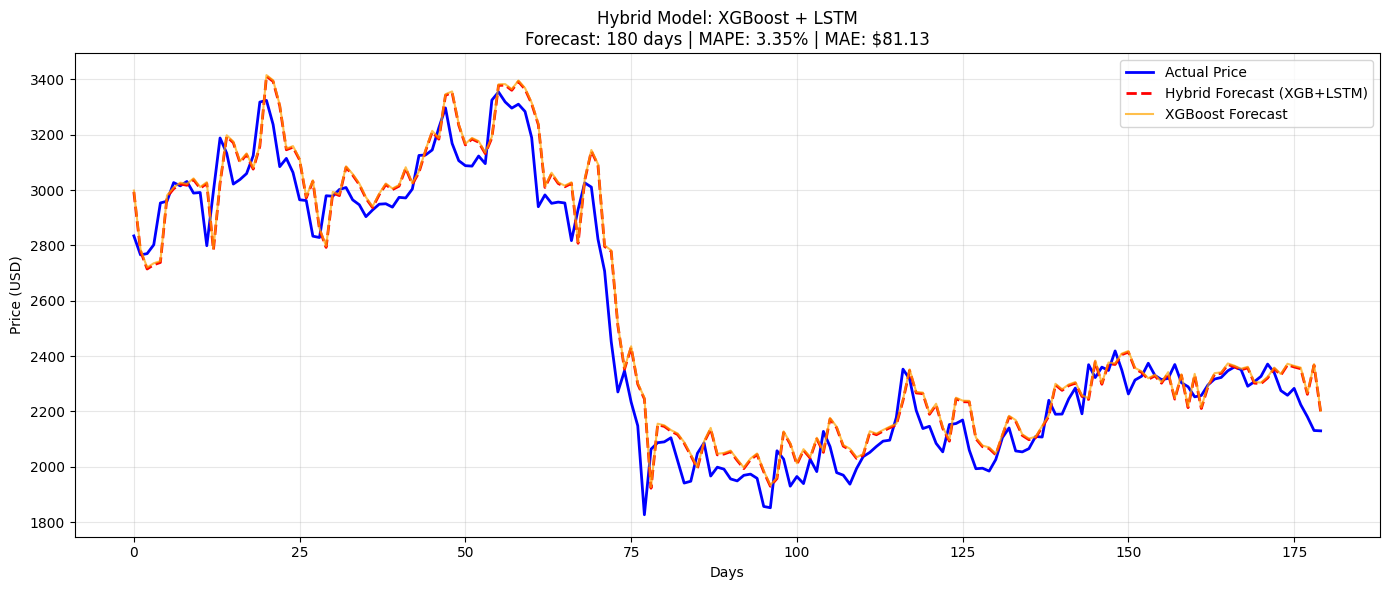

In [34]:
#ETH
eth_xgb_lstm = hybrid_forecast(eth_5years, forecast_days = 180, lags = 20, lookback = 20) 

   Shape X: (1822, 8) (=2 ценовых лагов + 6 др. лагов)

Training XGBoost...
Training LSTM on residuals...


d:\forecast_service\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



📊 РЕЗУЛЬТАТЫ:
   XGBoost MAPE: 8.21%
   Hybrid MAPE:  8.21%
   Улучшение:    0.00%
   MAE:          $0.13


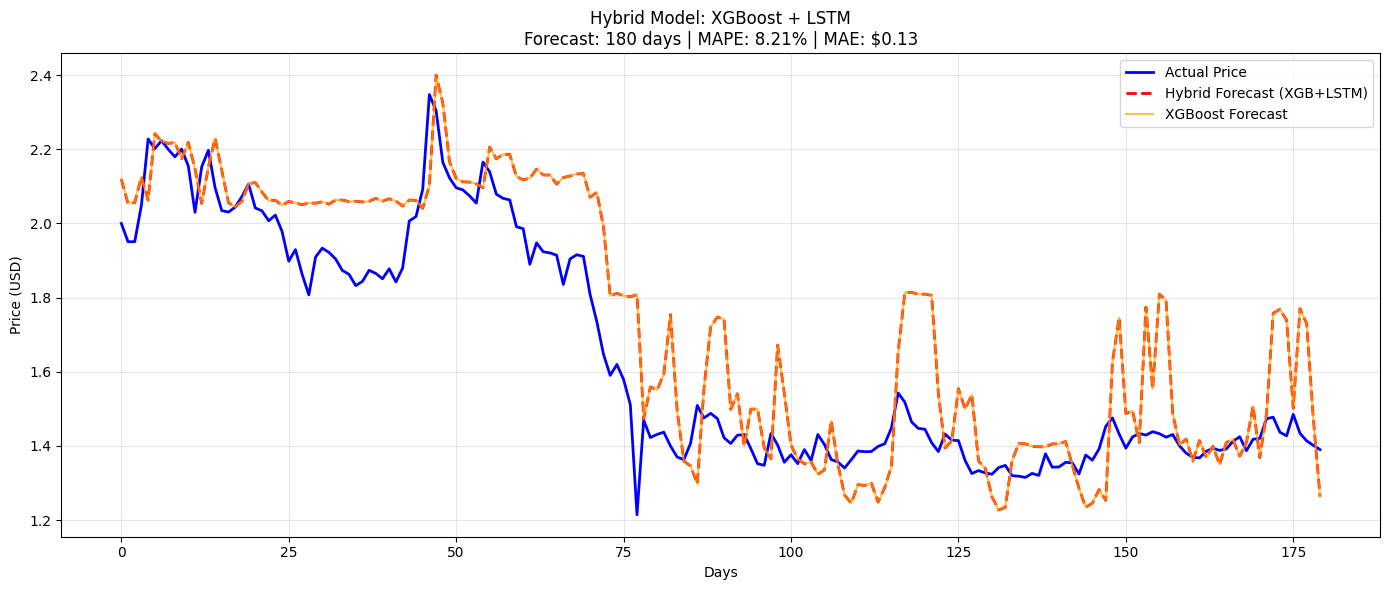

In [35]:
#XRP
xrp_xgb_lstm = hybrid_forecast(xrp_5years, forecast_days = 180, lags = 2, lookback = 2) 

   Shape X: (1804, 80) (=20 ценовых лагов + 60 др. лагов)

Training XGBoost...
Training LSTM on residuals...


d:\forecast_service\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



📊 РЕЗУЛЬТАТЫ:
   XGBoost MAPE: 2.83%
   Hybrid MAPE:  2.83%
   Улучшение:    -0.00%
   MAE:          $1.81


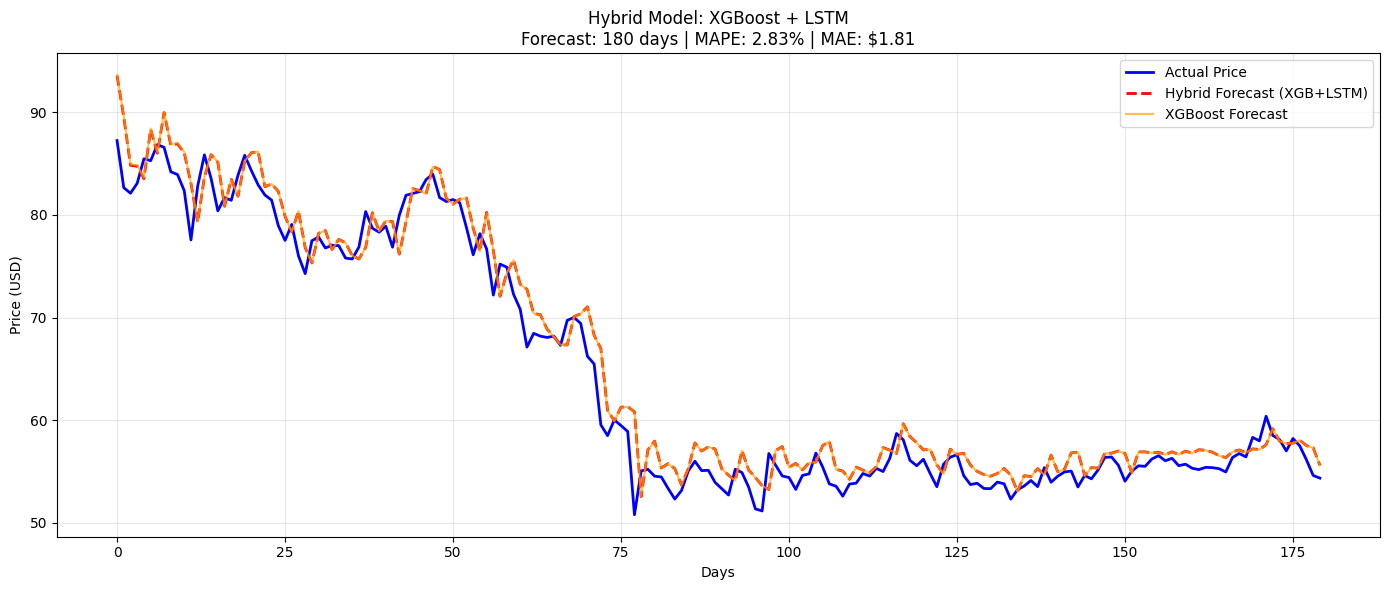

In [36]:
#LTC
ltc_xgb_lstm = hybrid_forecast(ltc_5years, forecast_days = 180, lags = 20, lookback = 20) 

## XGBOOST + TCN FORECASTS

In [37]:
def hybrid_forecast_tcn(data, forecast_days=30, lags=20, lookback=20, filters=64, kernel_size=3):
    feature_cols = [col for col in data.columns if col != 'close']
    price = data['close'].values
    
    # Создаём X с лагами ВСЕХ признаков
    X = []
    for i in range(lags, len(price)):
        row = []
        row.extend(price[i-lags:i])                     # лаги цены
        for col in feature_cols:
            row.extend(data[col].values[i-lags:i])      # лаги других признаков
        X.append(row)
    
    X = np.array(X)
    y = price[lags:]
    
    print(f"📊 Shape X: {X.shape} (={lags} ценовых лагов + {lags * len(feature_cols)} др. лагов)")
    
    # Train/test split
    split = len(X) - forecast_days
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    # ========== XGBoost ==========
    print("\nTraining XGBoost...")
    xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
    xgb.fit(X_train, y_train)
    xgb_train_pred = xgb.predict(X_train)
    xgb_test_pred = xgb.predict(X_test)
    
    # ========== TCN на остатках ==========
    print("Training TCN on residuals...")
    residuals = y_train - xgb_train_pred
    scaler = MinMaxScaler()
    res_scaled = scaler.fit_transform(residuals.reshape(-1, 1))
    
    # Подготовка последовательностей для TCN
    X_tcn, y_tcn = [], []
    for i in range(lookback, len(res_scaled)):
        X_tcn.append(res_scaled[i-lookback:i])
        y_tcn.append(res_scaled[i])
    X_tcn = np.array(X_tcn)
    y_tcn = np.array(y_tcn)
    
    
    # TCN архитектура (вместо LSTM)
    tcn_model = Sequential([
        Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', padding='causal', input_shape=(lookback, 1)),
        Dropout(0.2),
        Conv1D(filters=filters//2, kernel_size=kernel_size, activation='relu', padding='causal'),
        Dropout(0.2),
        GlobalAveragePooling1D(),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    tcn_model.compile(optimizer='adam', loss='mse')
    
    tcn_model.fit(X_tcn, y_tcn, epochs=50, batch_size=32, validation_split=0.2,
                  callbacks=[EarlyStopping(patience=5, restore_best_weights=True)], verbose=0, shuffle= False)
    
    # Прогноз остатков на тесте
    last_seq = scaler.transform(residuals[-lookback:].reshape(-1, 1)).flatten()
    residual_preds = []
    for _ in range(len(X_test)):
        pred = tcn_model.predict(last_seq.reshape(1, lookback, 1), verbose=0)[0, 0]
        residual_preds.append(pred)
        last_seq = np.append(last_seq[1:], pred)
    residual_preds = scaler.inverse_transform(np.array(residual_preds).reshape(-1, 1)).flatten()
    
    # Гибридный прогноз
    hybrid_pred = xgb_test_pred + residual_preds
    
    # Метрики
    mae = mean_absolute_error(y_test, hybrid_pred)
    mape = mean_absolute_percentage_error(y_test, hybrid_pred) * 100
    xgb_mape = mean_absolute_percentage_error(y_test, xgb_test_pred) * 100
    
    print(f"\n📊 РЕЗУЛЬТАТЫ:")
    print(f"   XGBoost MAPE: {xgb_mape:.2f}%")
    print(f"   Hybrid (XGB+TCN) MAPE:  {mape:.2f}%")
    print(f"   Улучшение:    {xgb_mape - mape:.2f}%")
    print(f"   MAE:          ${mae:,.2f}")
    
    # График
    plt.figure(figsize=(14, 6))
    plt.plot(y_test, label='Actual Price', linewidth=2, color='blue')
    plt.plot(hybrid_pred, label='Hybrid Forecast (XGB+TCN)', linewidth=2, color='red', linestyle='--')
    plt.plot(xgb_test_pred, label='XGBoost Forecast', linewidth=1.5, color='orange', alpha=0.7)
    plt.title(f'Hybrid Model: XGBoost + TCN\nForecast: {forecast_days} days | MAPE: {mape:.2f}% | MAE: ${mae:,.2f}')
    plt.xlabel('Days')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return {
        'predictions': hybrid_pred,
        'actual': y_test,
        'mae': mae,
        'mape': mape,
        'xgb_mape': xgb_mape,
        'models': {'xgb': xgb, 'tcn': tcn_model, 'scaler': scaler}
    }

📊 Shape X: (1804, 80) (=20 ценовых лагов + 60 др. лагов)

Training XGBoost...
Training TCN on residuals...


d:\forecast_service\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



📊 РЕЗУЛЬТАТЫ:
   XGBoost MAPE: 2.57%
   Hybrid (XGB+TCN) MAPE:  2.57%
   Улучшение:    0.01%
   MAE:          $1,984.23


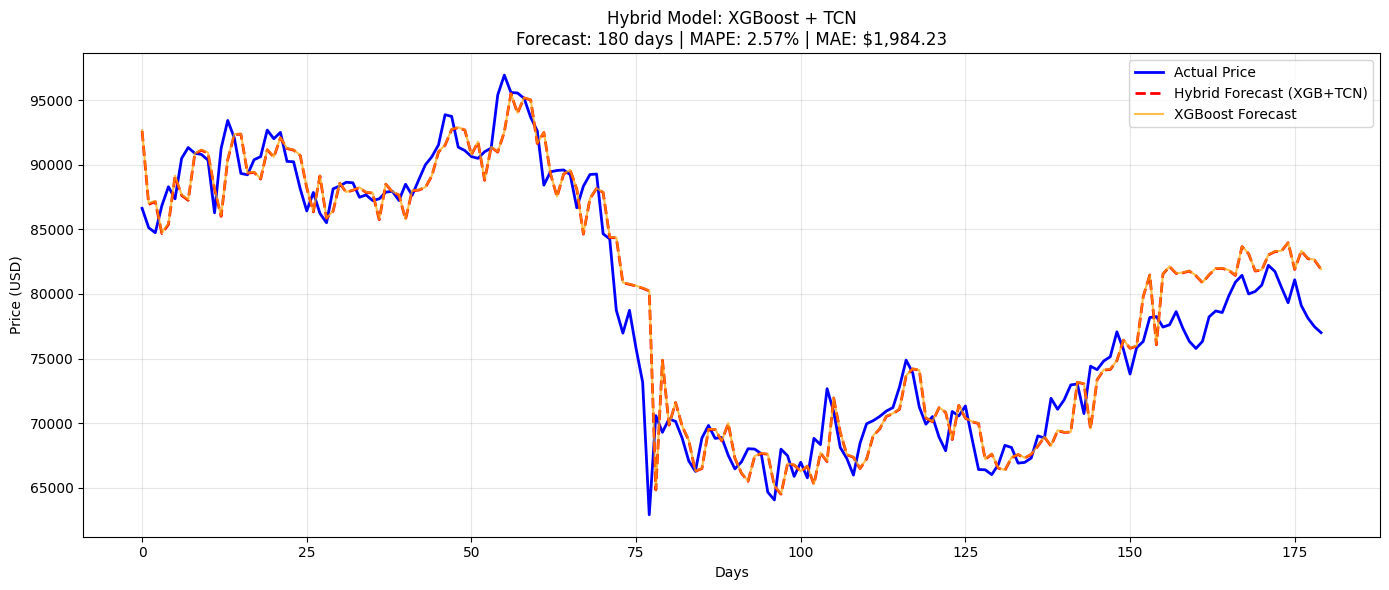

In [38]:
#btc
btc_xgb_tcn = hybrid_forecast_tcn(btc_5years, forecast_days = 180, lags = 20, lookback = 20, filters = 64, kernel_size = 3)

📊 Shape X: (1804, 80) (=20 ценовых лагов + 60 др. лагов)

Training XGBoost...
Training TCN on residuals...


d:\forecast_service\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



📊 РЕЗУЛЬТАТЫ:
   XGBoost MAPE: 3.44%
   Hybrid (XGB+TCN) MAPE:  3.19%
   Улучшение:    0.26%
   MAE:          $77.35


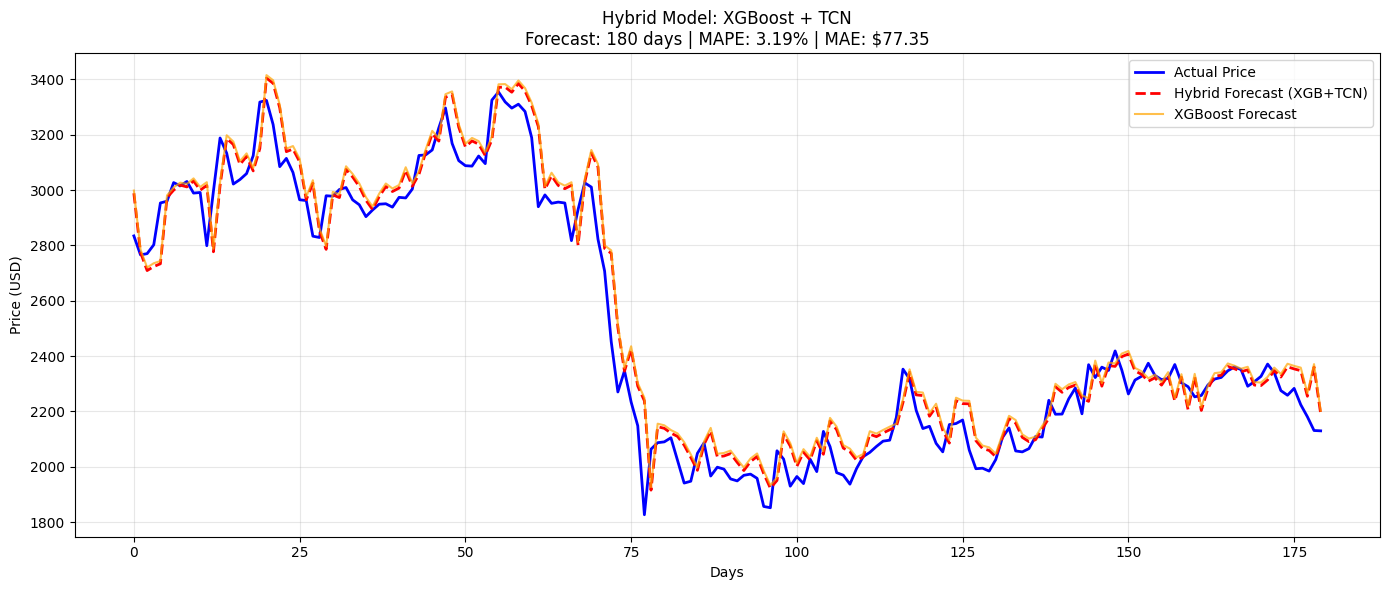

In [39]:
#eth
eth_xgb_tcn = hybrid_forecast_tcn(eth_5years, forecast_days = 180, lags = 20, lookback = 20, filters = 64, kernel_size = 3)

📊 Shape X: (1822, 8) (=2 ценовых лагов + 6 др. лагов)

Training XGBoost...
Training TCN on residuals...


d:\forecast_service\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



📊 РЕЗУЛЬТАТЫ:
   XGBoost MAPE: 8.21%
   Hybrid (XGB+TCN) MAPE:  8.11%
   Улучшение:    0.10%
   MAE:          $0.13


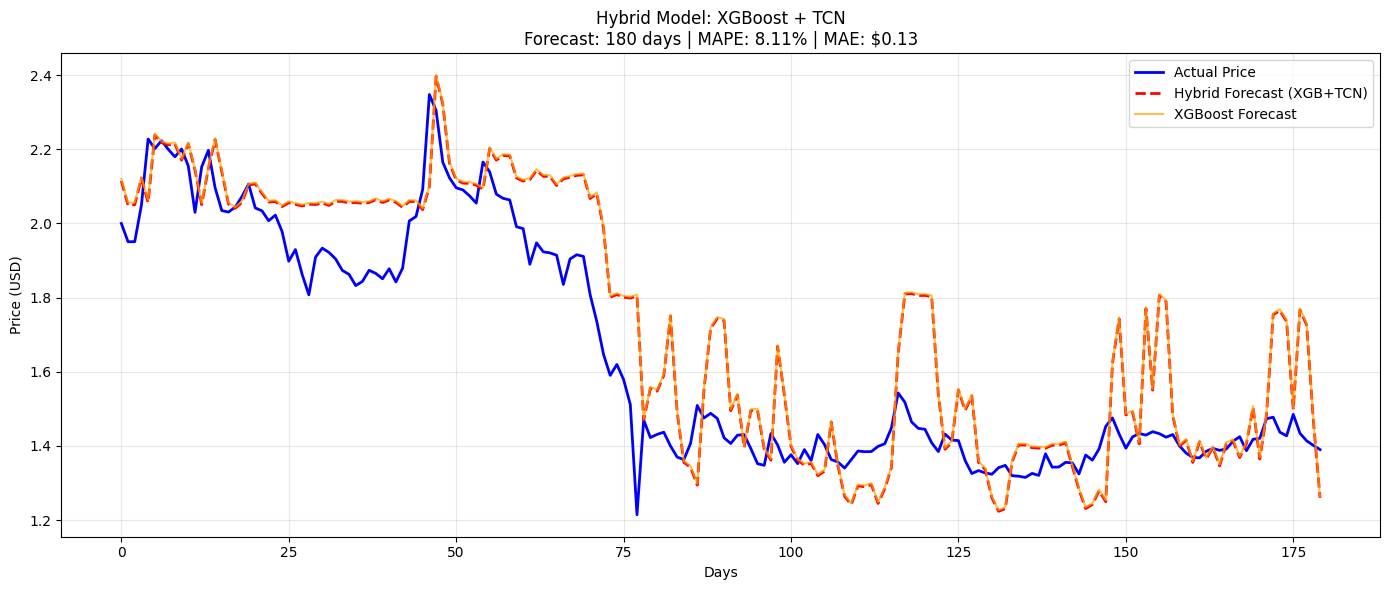

In [40]:
#xrp
xrp_xgb_tcn = hybrid_forecast_tcn(xrp_5years, forecast_days = 180, lags = 2, lookback = 5, filters = 128, kernel_size = 10)

📊 Shape X: (1804, 80) (=20 ценовых лагов + 60 др. лагов)

Training XGBoost...
Training TCN on residuals...


d:\forecast_service\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



📊 РЕЗУЛЬТАТЫ:
   XGBoost MAPE: 2.83%
   Hybrid (XGB+TCN) MAPE:  2.60%
   Улучшение:    0.22%
   MAE:          $1.68


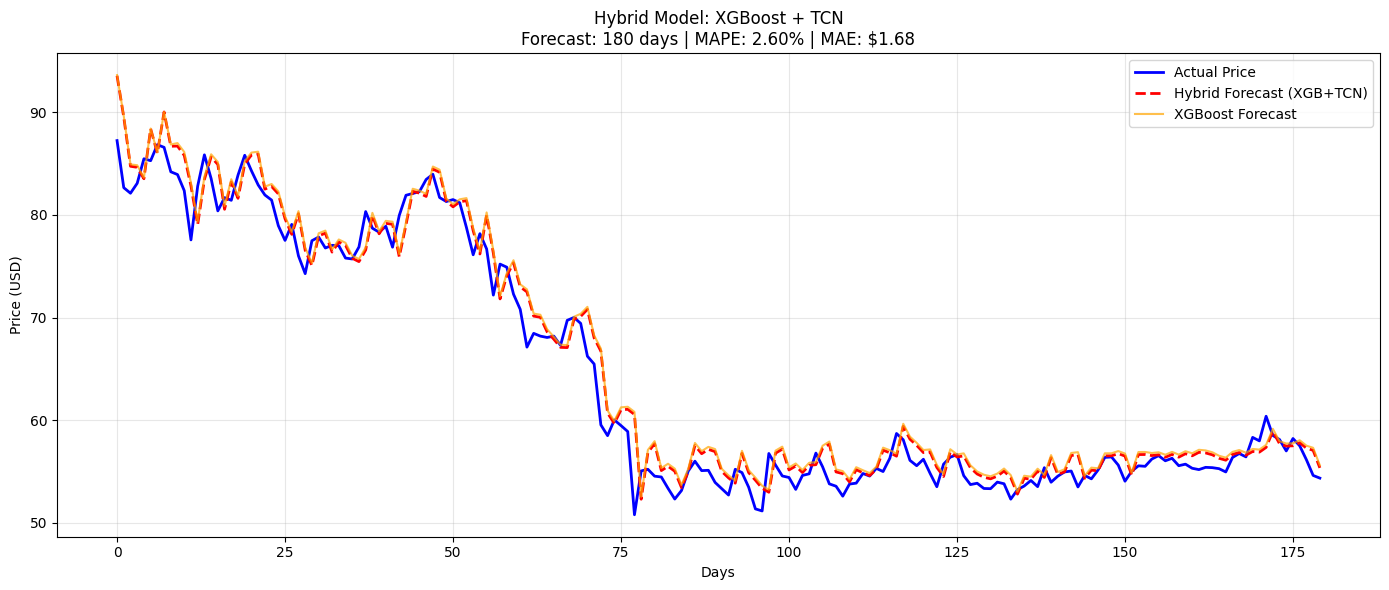

In [41]:
#ltc
ltc_xgb_tcn = hybrid_forecast_tcn(ltc_5years, forecast_days = 180, lags = 20, lookback = 20, filters = 64, kernel_size = 3)

## TCN + LSTM FORECASTS

In [42]:
def hybrid_forecast_tcn_lstm(data, forecast_days=30, lookback=20, 
                               tcn_filters=64, tcn_kernel=3, lstm_units=64):
 
    feature_cols = [col for col in data.columns if col != 'close']
    price = data['close'].values
    
    # Создаём последовательности для TCN+LSTM
    X_seq = []
    for i in range(lookback, len(price)):
        # Берём окно из ВСЕХ признаков
        window = []
        window.append(price[i-lookback:i])
        for col in feature_cols:
            window.append(data[col].values[i-lookback:i])
        X_seq.append(np.column_stack(window))
    
    X_seq = np.array(X_seq)  # shape: (samples, lookback, features)
    y = price[lookback:]
    
    print(f" Shape X: {X_seq.shape} (samples={len(X_seq)}, lookback={lookback}, features={X_seq.shape[2]})")
    
    # Train/test split
    split = len(X_seq) - forecast_days
    X_train, X_test = X_seq[:split], X_seq[split:]
    y_train, y_test = y[:split], y[split:]
    
    # Масштабирование
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
    X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)
    
    print(f"   Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")
    
    
    # Входной слой
    input_layer = Input(shape=(lookback, X_train.shape[2]))
    
    # Ветка TCN (Conv1D)
    tcn_out = Conv1D(filters=tcn_filters, kernel_size=tcn_kernel, 
                     activation='relu', padding='causal')(input_layer)
    tcn_out = Dropout(0.2)(tcn_out)
    tcn_out = Conv1D(filters=tcn_filters//2, kernel_size=tcn_kernel, 
                     activation='relu', padding='causal')(tcn_out)
    tcn_out = Dropout(0.2)(tcn_out)
    tcn_out = GlobalAveragePooling1D()(tcn_out)
    
    # Ветка LSTM
    lstm_out = LSTM(lstm_units, return_sequences=False)(input_layer)
    lstm_out = Dropout(0.2)(lstm_out)
    # lstm_out = Dense(8, activation='relu')(lstm_out)
    
    # Объединение веток
    concatenated = Concatenate()([tcn_out, lstm_out])
    
    # Общие слои
    dense1 = Dense(32, activation='relu')(concatenated)
    dropout = Dropout(0.3)(dense1)
    output = Dense(1)(dropout)
    
    # Модель
    model = Model(inputs=input_layer, outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    early_stop = EarlyStopping(patience=10, restore_best_weights=True, verbose=0)
    
    history = model.fit(
        X_train_scaled, y_train,
        shuffle= False,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )
    
    # Прогноз
    print("\n Making predictions...")
    train_pred = model.predict(X_train_scaled, verbose=0).flatten()
    test_pred = model.predict(X_test_scaled, verbose=0).flatten()
    
    # Метрики
    train_mae = mean_absolute_error(y_train, train_pred)
    train_mape = mean_absolute_percentage_error(y_train, train_pred) * 100
    test_mae = mean_absolute_error(y_test, test_pred)
    test_mape = mean_absolute_percentage_error(y_test, test_pred) * 100
    
    print(f"\n РЕЗУЛЬТАТЫ:")
    print(f"   Train MAE:  ${train_mae:,.2f} | MAPE: {train_mape:.2f}%")
    print(f"   Test MAE:   ${test_mae:,.2f} | MAPE: {test_mape:.2f}%")
    
    # График потерь
    plt.figure(figsize=(14, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # График прогноза
    plt.subplot(1, 2, 2)
    plt.plot(y_test, label='Actual Price', linewidth=2, color='blue')
    plt.plot(test_pred, label='TCN+LSTM Forecast', linewidth=2, color='red', linestyle='--')
    plt.title(f'TCN + LSTM Hybrid\nTest MAPE: {test_mape:.2f}% | MAE: ${test_mae:,.2f}')
    plt.xlabel('Days')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    
    return {
        'test_mae': test_mae,
        'test_mape': test_mape,
        'model': model,
        'scaler': scaler,
        'history': history.history
    }


 Shape X: (1814, 10, 4) (samples=1814, lookback=10, features=4)
   Train: (1634, 10, 4), Test: (180, 10, 4)

 Making predictions...

 РЕЗУЛЬТАТЫ:
   Train MAE:  $2,943.92 | MAPE: 5.94%
   Test MAE:   $3,609.43 | MAPE: 4.57%


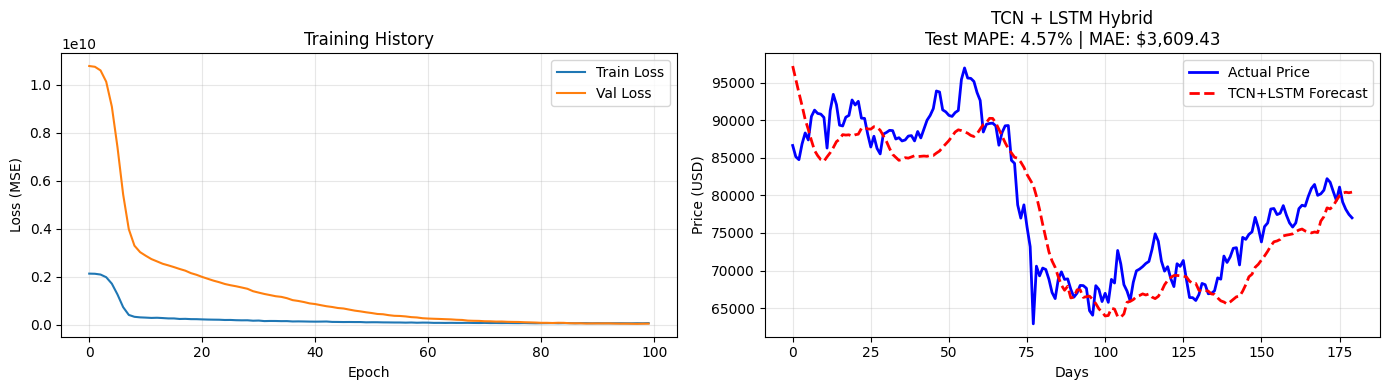

In [43]:
#btc
btc_tcn_lstm = hybrid_forecast_tcn_lstm(btc_5years, forecast_days = 180, lookback = 10, tcn_filters=64, tcn_kernel=4, lstm_units=64)

 Shape X: (1804, 20, 4) (samples=1804, lookback=20, features=4)
   Train: (1624, 20, 4), Test: (180, 20, 4)

 Making predictions...

 РЕЗУЛЬТАТЫ:
   Train MAE:  $216.29 | MAPE: 8.52%
   Test MAE:   $1,226.75 | MAPE: 53.53%


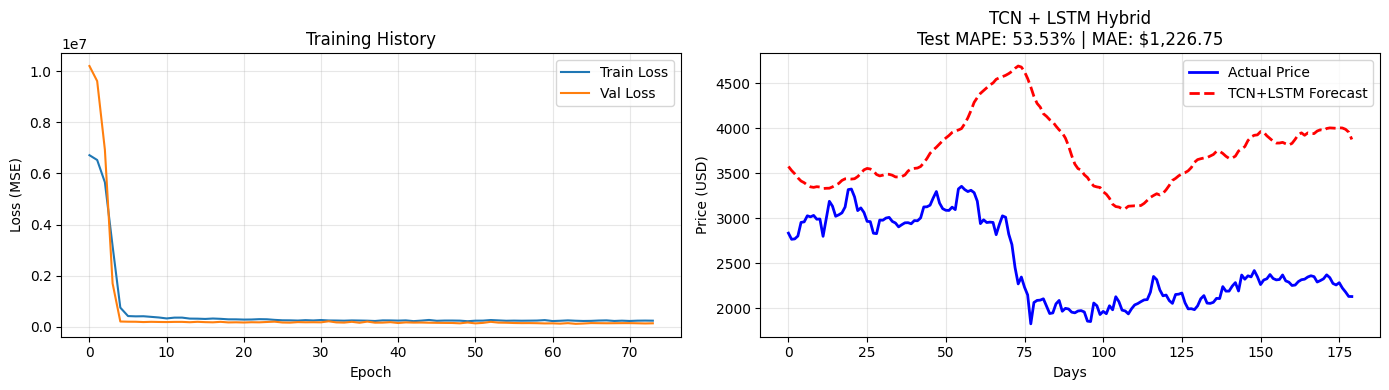

In [44]:
#eth
eth_tcn_lstm = hybrid_forecast_tcn_lstm(eth_5years, forecast_days=180, lookback=20, tcn_filters=64, tcn_kernel=3, lstm_units=64)

 Shape X: (1804, 20, 4) (samples=1804, lookback=20, features=4)
   Train: (1624, 20, 4), Test: (180, 20, 4)

 Making predictions...

 РЕЗУЛЬТАТЫ:
   Train MAE:  $0.06 | MAPE: 5.49%
   Test MAE:   $0.09 | MAPE: 5.65%


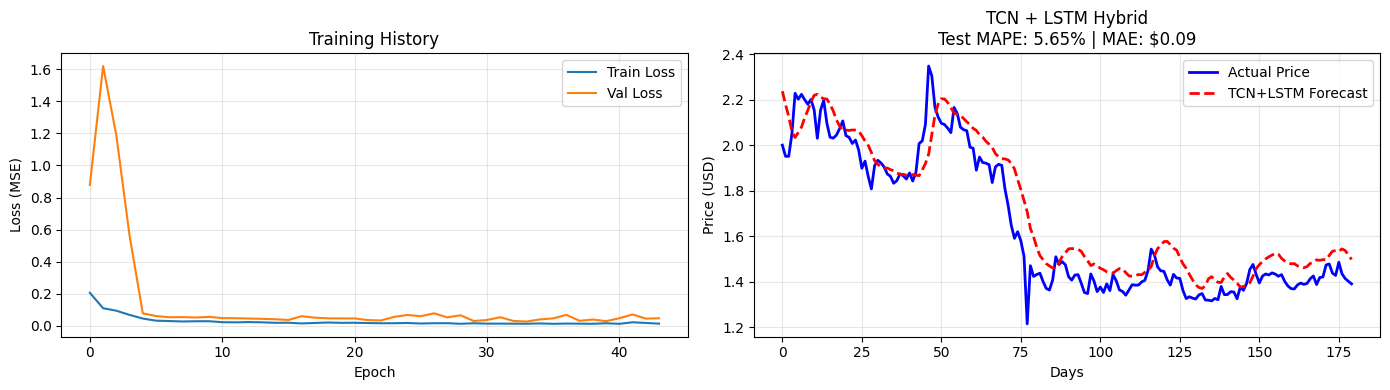

In [45]:
#xrp
xrp_tcn_lstm = hybrid_forecast_tcn_lstm(xrp_5years, forecast_days=180, lookback=20, tcn_filters=64, tcn_kernel=3, lstm_units=64)

 Shape X: (1804, 20, 4) (samples=1804, lookback=20, features=4)
   Train: (1624, 20, 4), Test: (180, 20, 4)

 Making predictions...

 РЕЗУЛЬТАТЫ:
   Train MAE:  $8.20 | MAPE: 8.01%
   Test MAE:   $3.95 | MAPE: 6.02%


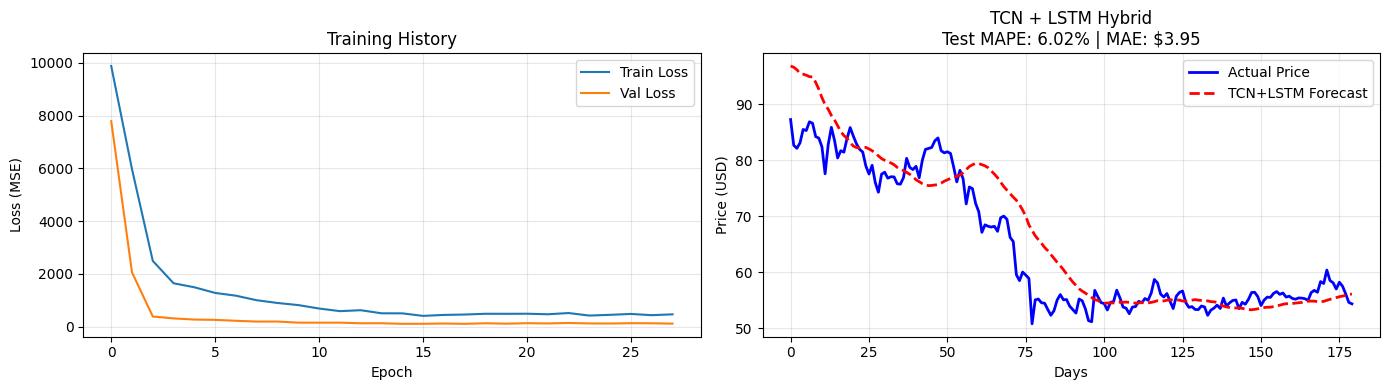

In [46]:
#ltc
ltc_tcn_lstm = hybrid_forecast_tcn_lstm(ltc_5years, forecast_days=180, lookback=20, tcn_filters=64, tcn_kernel=3, lstm_units=64)

## Сохранение моделей

In [79]:
import pickle
import os
import json
from datetime import date

# Создаём папку для моделей
os.makedirs("../models", exist_ok=True)

# ============================================
# 1. XRP: TCN + LSTM
# ============================================
os.makedirs("../models/xrp_tcn_lstm_180", exist_ok=True)

xrp_tcn_lstm['model'].save("../models/xrp_tcn_lstm_180/model.keras")

with open("../models/xrp_tcn_lstm_180/scaler.pkl", "wb") as f:
    pickle.dump(xrp_tcn_lstm['scaler'], f)

# ИСПРАВЛЕНО: добавил lookback!
metadata = {
    'symbol': 'XRP',
    'model_type': 'tcn_lstm',
    'horizon': 180,
    'lookback': 20,
    'feature_cols': [
        'volume',
        'active_addresses',
        'tx_count'
    ],
    'test_mape': float(xrp_tcn_lstm['test_mape'])
}
with open("../models/xrp_tcn_lstm_180/metadata.json", "w") as f:
    json.dump(metadata, f)

print("✅ XRP model saved (lookback=20)")

# ============================================
# 2. BTC: XGB + LSTM (lags=10, lookback=50)
# ============================================
os.makedirs("../models/btc_xgb_lstm_180", exist_ok=True)

with open("../models/btc_xgb_lstm_180/xgb_model.pkl", "wb") as f:
    pickle.dump(btc_xgb_lstm['models']['xgb'], f)

btc_xgb_lstm['models']['lstm'].save("../models/btc_xgb_lstm_180/lstm_model.keras")

with open("../models/btc_xgb_lstm_180/scaler.pkl", "wb") as f:
    pickle.dump(btc_xgb_lstm['models']['scaler'], f)

metadata = {
    'symbol': 'BTC',
    'model_type': 'xgb_lstm',
    'horizon': 180,
    'lags': 10,
    'lookback': 50,
    'feature_cols': [
        'volume',
        'active_addresses',
        'tx_count'
    ],
    'test_mape': float(btc_xgb_lstm['mape'])
}
with open("../models/btc_xgb_lstm_180/metadata.json", "w") as f:
    json.dump(metadata, f)

print("✅ BTC model saved (lags=10, lookback=50)")

# ============================================
# 3. LTC: XGB + LSTM (lags=20, lookback=20)
# ============================================
os.makedirs("../models/ltc_xgb_lstm_180", exist_ok=True)

with open("../models/ltc_xgb_lstm_180/xgb_model.pkl", "wb") as f:
    pickle.dump(ltc_xgb_lstm['models']['xgb'], f)

ltc_xgb_lstm['models']['lstm'].save("../models/ltc_xgb_lstm_180/lstm_model.keras")

with open("../models/ltc_xgb_lstm_180/scaler.pkl", "wb") as f:
    pickle.dump(ltc_xgb_lstm['models']['scaler'], f)

metadata = {
    'symbol': 'LTC',
    'model_type': 'xgb_lstm',
    'horizon': 180,
    'lags': 20,
    'lookback': 20,
    'feature_cols': [
        'volume',
        'active_addresses',
        'tx_count'
    ],
    'test_mape': float(ltc_xgb_lstm['mape'])
}
with open("../models/ltc_xgb_lstm_180/metadata.json", "w") as f:
    json.dump(metadata, f)

print("✅ LTC model saved (lags=20, lookback=20)")

# ============================================
# 4. ETH: XGB + TCN (lags=20, lookback=20)
# ============================================
os.makedirs("../models/eth_xgb_tcn_180", exist_ok=True)

with open("../models/eth_xgb_tcn_180/xgb_model.pkl", "wb") as f:
    pickle.dump(eth_xgb_tcn['models']['xgb'], f)

eth_xgb_tcn['models']['tcn'].save("../models/eth_xgb_tcn_180/tcn_model.keras")

with open("../models/eth_xgb_tcn_180/scaler.pkl", "wb") as f:
    pickle.dump(eth_xgb_tcn['models']['scaler'], f)

metadata = {
    'symbol': 'ETH',
    'model_type': 'xgb_tcn',
    'horizon': 180,
    'lags': 20,
    'lookback': 20,
    'feature_cols': [
        'volume',
        'active_addresses',
        'tx_count'
    ],
    'test_mape': float(eth_xgb_tcn['mape'])
}
with open("../models/eth_xgb_tcn_180/metadata.json", "w") as f:
    json.dump(metadata, f)

print("✅ ETH model saved (lags=20, lookback=20)")

print("\n✅ Все модели сохранены в папку ../models/")

✅ XRP model saved (lookback=20)
✅ BTC model saved (lags=10, lookback=50)
✅ LTC model saved (lags=20, lookback=20)
✅ ETH model saved (lags=20, lookback=20)

✅ Все модели сохранены в папку ../models/


In [91]:
def train_hybrid_model(data, lags=20, lookback=20):
    
    feature_cols = [c for c in data.columns if c != "close"]
    price = data["close"].values
    
    # =========================
    # XGBOOST DATASET
    # =========================
    X, y = [], []
    
    for i in range(lags, len(price)):
        row = []
        
        row.extend(price[i-lags:i])
        
        for col in feature_cols:
            row.extend(data[col].values[i-lags:i])
        
        X.append(row)
        y.append(price[i])
    
    X = np.array(X)
    y = np.array(y)
    
    split = int(len(X) * 0.8)
    
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    # =========================
    # XGBOOST
    # =========================
    xgb = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
    
    xgb.fit(X_train, y_train)
    
    xgb_train_pred = xgb.predict(X_train)
    xgb_test_pred = xgb.predict(X_test)
    
    # =========================
    # LSTM ON RESIDUALS
    # =========================
    residuals = y_train - xgb_train_pred
    
    scaler = MinMaxScaler()
    res_scaled = scaler.fit_transform(residuals.reshape(-1, 1))
    
    X_lstm, y_lstm = [], []
    
    for i in range(lookback, len(res_scaled)):
        X_lstm.append(res_scaled[i-lookback:i])
        y_lstm.append(res_scaled[i])
    
    X_lstm = np.array(X_lstm)
    y_lstm = np.array(y_lstm)
    
    lstm = Sequential([
        LSTM(64, return_sequences=True, input_shape=(lookback, 1)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    
    lstm.compile(optimizer="adam", loss="mse")
    
    lstm.fit(
        X_lstm, y_lstm,
        epochs=30,
        batch_size=32,
        validation_split=0.2,
        shuffle=False,
        verbose=0,
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
    )
    
    return {
        "xgb": xgb,
        "lstm": lstm,
        "scaler": scaler,
        "lags": lags,
        "lookback": lookback,
        "feature_cols": feature_cols,
        "xgb_test_pred": xgb_test_pred,
        "y_test": y_test
    }

In [92]:
def forecast_hybrid(model_pack, data, horizon=180):
    
    xgb = model_pack["xgb"]
    lstm = model_pack["lstm"]
    scaler = model_pack["scaler"]
    
    lags = model_pack["lags"]
    lookback = model_pack["lookback"]
    feature_cols = model_pack["feature_cols"]
    
    price = data["close"].values.copy()
    
    residual_history = []
    predictions = []
    
    for _ in range(horizon):
        
        # =====================
        # XGB INPUT
        # =====================
        row = []
        
        row.extend(price[-lags:])
        
        for col in feature_cols:
            row.extend(data[col].values[-lags:])
        
        xgb_input = np.array(row).reshape(1, -1)
        xgb_pred = xgb.predict(xgb_input)[0]
        
        # =====================
        # LSTM RESIDUAL
        # =====================
        if len(residual_history) < lookback:
            padded = [0]*(lookback - len(residual_history)) + residual_history
        else:
            padded = residual_history[-lookback:]
        
        lstm_in = scaler.transform(np.array(padded).reshape(-1, 1))
        lstm_in = lstm_in.reshape(1, lookback, 1)
        
        res_scaled = lstm.predict(lstm_in, verbose=0)[0, 0]
        res = scaler.inverse_transform([[res_scaled]])[0, 0]
        
        # =====================
        # FINAL
        # =====================
        final = xgb_pred + res
        
        predictions.append(final)
        residual_history.append(res)
        
        # обновляем price (важно)
        price = np.append(price, final)
    
    return np.array(predictions)

In [93]:
model = train_hybrid_model(btc_5years, lags=20, lookback=20)

forecast_180 = forecast_hybrid(model, btc_5years, horizon=180)

d:\forecast_service\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


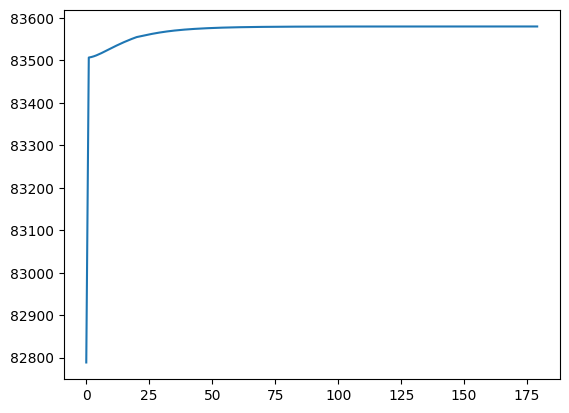

In [94]:
plt.plot(forecast_180)